# [Image Segmentation (`photutils.segmentation`)](https://photutils.readthedocs.io/en/latest/reference/segmentation_api.html#module-photutils.segmentation)

Photutils includes general-use functions to detect sources (both point-like and extended) in an image using a process called image segmentation. After detecting sources using [image segmentation](https://en.wikipedia.org/wiki/Image_segmentation), we can then measure their photometry, centroids, and shape properties.

## Source Extraction Using Image Segmentation

Let’s start by making a synthetic image provided by the [photutils.datasets](https://photutils.readthedocs.io/en/latest/user_guide/datasets.html#datasets) module:

In [14]:
from photutils.datasets import make_100gaussians_image
from photutils.background import Background2D, MedianBackground
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel, detect_sources, deblend_sources, SourceFinder
from astropy.visualization import simple_norm
from photutils.utils import circular_footprint

import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = make_100gaussians_image()

bkg_estimator = MedianBackground()
bkg = Background2D(data, (50, 50), filter_size=(3, 3), bkg_estimator=bkg_estimator)
data -= bkg.background 

# In this example, we’ll define a 2D detection threshold image using the background RMS image. 
# We set the threshold at the 1.5-sigma (per pixel) noise level:

threshold = 1.5 * bkg.background_rms

# Next, let’s convolve the data with a 2D Gaussian kernel with a FWHM of 3 pixels:

kernel = make_2dgaussian_kernel(3.0, size=5)
convolved_data = convolve(data, kernel)

Now we are ready to detect the sources in the background-subtracted convolved image. Let’s find sources that have 10 connected pixels that are each greater than the corresponding pixel-wise `threshold` level defined above (i.e., 1.5 sigma per pixel above the background noise).

Note that by default “connected pixels” means “8-connected” pixels, where pixels touch along their edges or corners. One can also use “4-connected” pixels that touch only along their edges by setting `connectivity=4`:

In [4]:
segment_map = detect_sources(convolved_data, threshold, n_pixels=10)
print(segment_map)

<photutils.segmentation.core.SegmentationImage>
shape: (300, 500)
n_labels: 86
labels: [ 1  2  3  4  5 ... 82 83 84 85 86]


The result is a [SegmentationImage](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SegmentationImage.html#photutils.segmentation.SegmentationImage) object with the same shape as the data, where detected sources are labeled by different positive integer values. Background pixels (non-sources) always have a value of zero. Because the segmentation image is generated using image thresholding, the source segments represent the isophotal footprints of each source.

Let’s plot both the background-subtracted image and the segmentation image showing the detected sources:

Text(0.5, 1.0, 'Segmentation Image')

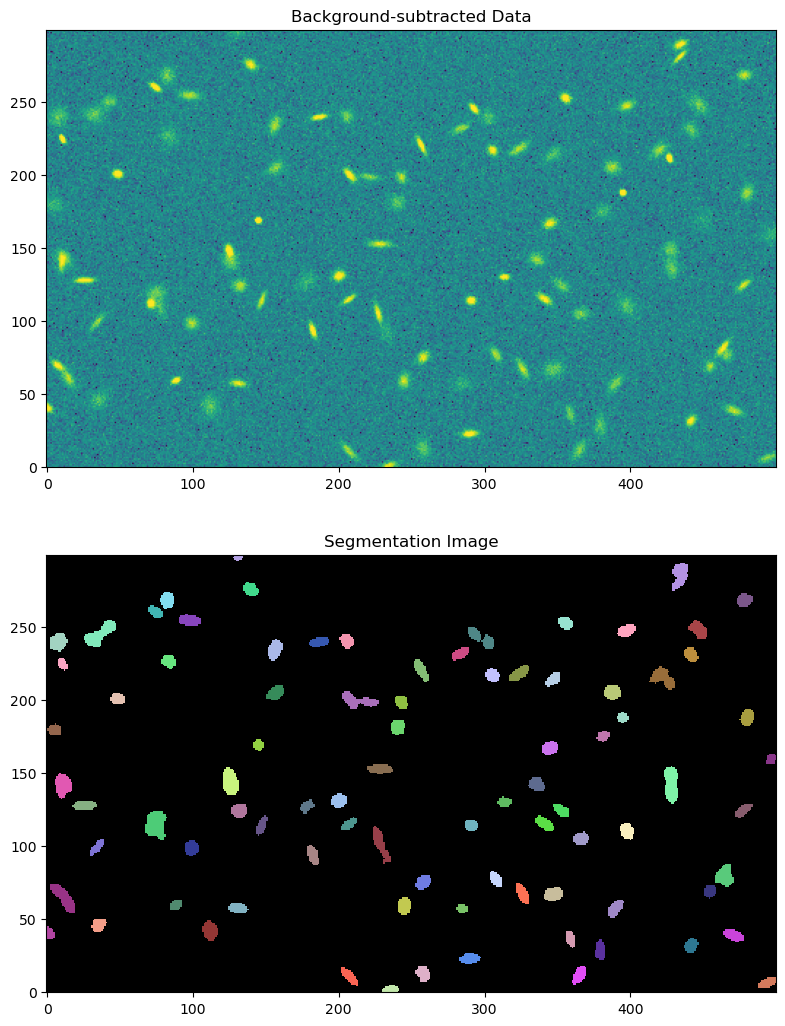

In [5]:
norm = simple_norm(data, 'sqrt', percent=99.5)

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 12.5))
ax1.imshow(data, norm=norm, origin='lower')
ax1.set_title('Background-subtracted Data')
segment_map.imshow(ax=ax2)
ax2.set_title('Segmentation Image')

## Source Deblending

In the example above, overlapping sources are detected as single sources. Separating those sources requires a deblending procedure, such as a multi-thresholding technique used by [SourceExtractor](https://sextractor.readthedocs.io/en/latest/). Photutils provides a [`deblend_sources()`](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.deblend_sources.html#photutils.segmentation.deblend_sources) function that deblends sources using a combination of multi-thresholding and [watershed segmentation](https://en.wikipedia.org/wiki/Watershed_(image_processing)). Note that in order to deblend sources, they must be separated enough that there is a saddle point between them.

In [6]:
segment_map2 = deblend_sources(convolved_data, segment_map,
                               n_pixels=10, n_levels=32, contrast=0.001,
                               progress_bar=False)

where `segment_map` is the [SegmentationImage](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SegmentationImage.html#photutils.segmentation.SegmentationImage) that was generated by [detect_sources()](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.detect_sources.html#photutils.segmentation.detect_sources). Note that the `convolved_data` and `n_pixels` input values should match those used in [detect_sources()](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.detect_sources.html#photutils.segmentation.detect_sources) to generate `segment_map`. The result is a new [SegmentationImage](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SegmentationImage.html#photutils.segmentation.SegmentationImage) object containing the deblended segmentation image:

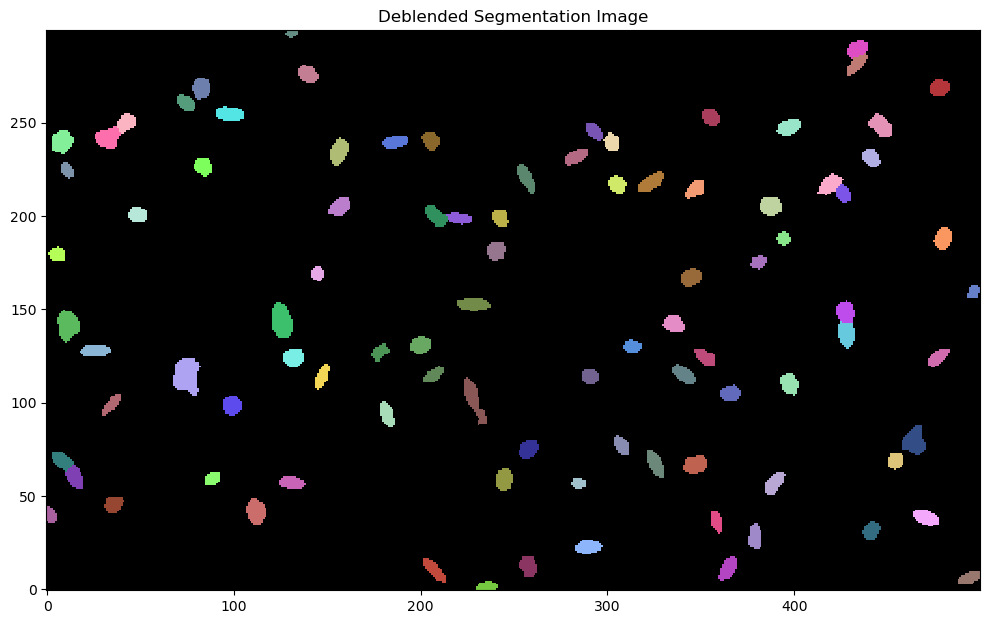

In [8]:
n_pixels = 10
segment_map = detect_sources(convolved_data, threshold, n_pixels=n_pixels)
deblended_segment_map = deblend_sources(convolved_data, segment_map,
                                        n_pixels=n_pixels,
                                        progress_bar=False)

fig, ax = plt.subplots(figsize=(10, 6.5))
deblended_segment_map.imshow(ax=ax)
ax.set_title('Deblended Segmentation Image')
fig.tight_layout()

Let’s plot one of the deblended sources:

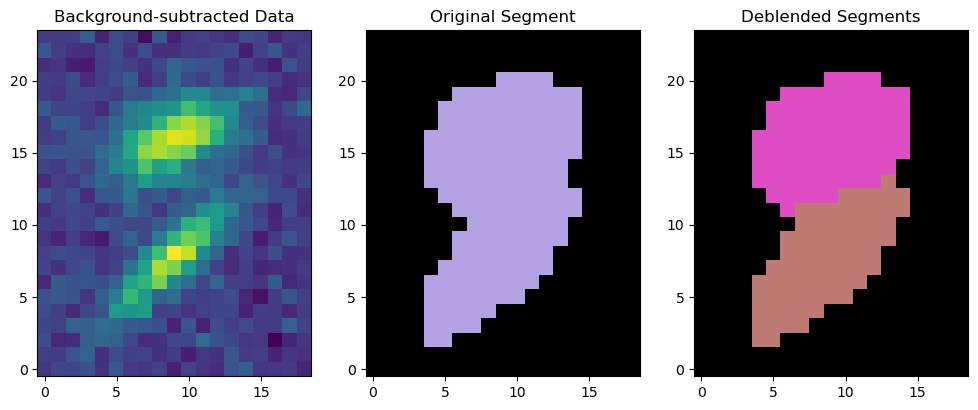

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(10, 4))
slc = (slice(273, 297), slice(425, 444))
ax1.imshow(data[slc], origin='lower')
ax1.set_title('Background-subtracted Data')

segm_cutout = segment_map[slc]
segm_cutout.imshow(ax=ax2, cmap=segment_map.cmap)
ax2.set_title('Original Segment')

deblended_segm_cutout = deblended_segment_map[slc]
deblended_segm_cutout.imshow(ax=ax3, cmap=deblended_segment_map.cmap)
ax3.set_title('Deblended Segments')
fig.tight_layout()

## SourceFinder

The [SourceFinder](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SourceFinder.html#photutils.segmentation.SourceFinder) class is a convenience class that combines the functionality of [detect_sources](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.detect_sources.html#photutils.segmentation.detect_sources) and [deblend_sources](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.deblend_sources.html#photutils.segmentation.deblend_sources). After defining the object with the desired detection and deblending parameters, you call it with the background-subtracted (convolved) image and threshold:

In [11]:
finder = SourceFinder(n_pixels=10, progress_bar=False)
segent_map = finder(convolved_data, threshold)
print(segment_map)

<photutils.segmentation.core.SegmentationImage>
shape: (300, 500)
n_labels: 86
labels: [ 1  2  3  4  5 ... 82 83 84 85 86]


## Modifying a Segmentation Image

Here’s a simple example of removing border labels and relabeling the result:

In [12]:
segment_map3 = segment_map.copy()
segment_map3.remove_border_labels(border_width=10, relabel=True)
print(segment_map3)

<photutils.segmentation.core.SegmentationImage>
shape: (300, 500)
n_labels: 72
labels: [ 1  2  3  4  5 ... 68 69 70 71 72]


## Source Masks

[make_source_mask()](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SegmentationImage.html#photutils.segmentation.SegmentationImage.make_source_mask)

In [13]:
mask = segment_map.make_source_mask()
dilated_mask = segment_map.make_source_mask(size=11)

A circular footprint can also be used to dilate the source mask:

In [16]:
footprint = circular_footprint(radius=5)
dilated_mask2 = segment_map.make_source_mask(footprint=footprint)

Note that using a square footprint (via the `size` keyword) is much faster than using other shapes (e.g., a circular footprint).

## Polygons and Regions